# BST and Treap classes (trees.py)

In this section, we import our custom tree implementations from `trees.py`.
BST is ordered by timestamp only, while Treap is ordered by timestamp but uses score as heap priority.


In [4]:
%%writefile trees.py

# ======= trees.py =======

# ------------- BST IMPLEMENTATION ------------- #

class BSTNode:
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.left = None
        self.right = None


class BSTFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}

    # ----- Public API ----- #

    def addPost(self, post_id, timestamp, score):
        node = BSTNode(post_id, timestamp, score)
        self.root = self._insert_iterative(self.root, node)
        self.id_map[post_id] = node

    def likePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is not None:
            node.score += 1

    def deletePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        pid = node.post_id
        self.root = self._delete_iterative(self.root, ts, pid)
        self.id_map.pop(post_id, None)

    def getMostPopular(self):
        if self.root is None:
            return None
        best = self._max_score_node(self.root)
        return (best.post_id, best.timestamp, best.score)

    def getMostRecent(self, k):
        result = []
        self._reverse_inorder_recent(self.root, k, result)
        return [(n.post_id, n.timestamp, n.score) for n in result]

    # ----- Internal helpers ----- #

    def _insert_iterative(self, root, node):
        """Iterative insert to avoid recursion depth issues."""
        if root is None:
            return node

        curr = root
        while True:
            if (node.timestamp, node.post_id) < (curr.timestamp, curr.post_id):
                if curr.left is None:
                    curr.left = node
                    break
                curr = curr.left
            else:
                if curr.right is None:
                    curr.right = node
                    break
                curr = curr.right
        return root

    def _delete_iterative(self, root, ts, post_id):
        """Fully iterative BST delete by (timestamp, post_id)."""
        if root is None:
            return None

        key = (ts, post_id)
        parent = None
        curr = root

        # 1) Find the node and its parent
        while curr is not None:
            curr_key = (curr.timestamp, curr.post_id)
            if key < curr_key:
                parent = curr
                curr = curr.left
            elif key > curr_key:
                parent = curr
                curr = curr.right
            else:
                break

        if curr is None:
            # not found
            return root

        # helper to replace child pointer from parent
        def replace_child(parent_node, old_child, new_child):
            nonlocal root
            if parent_node is None:
                root = new_child
            else:
                if parent_node.left is old_child:
                    parent_node.left = new_child
                else:
                    parent_node.right = new_child

        # 2) If node has at most one child, easy case
        if curr.left is None or curr.right is None:
            child = curr.left if curr.left is not None else curr.right
            replace_child(parent, curr, child)
            return root

        # 3) Two-children case: find inorder successor (min in right subtree)
        succ_parent = curr
        succ = curr.right
        while succ.left is not None:
            succ_parent = succ
            succ = succ.left

        # Copy successor data into current node
        curr.post_id = succ.post_id
        curr.timestamp = succ.timestamp
        curr.score = succ.score

        # Update id_map so this post_id points to curr
        self.id_map[curr.post_id] = curr

        # Now delete the successor node (succ) which has at most one child (no left)
        child = succ.right  # succ.left is None by construction
        if succ_parent.left is succ:
            succ_parent.left = child
        else:
            succ_parent.right = child

        return root

    def _min_node(self, node):
        curr = node
        while curr.left is not None:
            curr = curr.left
        return curr

    def _max_score_node(self, node):
        # iterative traversal to find max score
        stack = [node]
        best = node
        while stack:
            n = stack.pop()
            if n.score > best.score:
                best = n
            if n.left:
                stack.append(n.left)
            if n.right:
                stack.append(n.right)
        return best

    def _reverse_inorder_recent(self, node, k, acc_list):
        # iterative reverse inorder to avoid recursion
        stack = []
        curr = node
        while (stack or curr) and len(acc_list) < k:
            while curr:
                stack.append(curr)
                curr = curr.right
            curr = stack.pop()
            acc_list.append(curr)
            curr = curr.left

    def height(self):
        """Iterative height using BFS (no recursion)."""
        if self.root is None:
            return -1
        from collections import deque
        q = deque([(self.root, 0)])
        max_h = 0
        while q:
            node, h = q.popleft()
            max_h = max(max_h, h)
            if node.left:
                q.append((node.left, h+1))
            if node.right:
                q.append((node.right, h+1))
        return max_h


# ------------- TREAP IMPLEMENTATION ------------- #

class TreapNode:
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.priority = score
        self.left = None
        self.right = None


class TreapFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}
        self.rotation_count = 0

    # ----- Public API ----- #

    def addPost(self, post_id, timestamp, score):
        node = TreapNode(post_id, timestamp, score)
        self.root = self._insert_iterative(self.root, node)
        self.id_map[post_id] = node

    def likePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        new_score = node.score + 1
        # remove from treap structure only
        self._delete_only_tree(post_id, ts)
        # remove from map
        self.id_map.pop(post_id, None)
        # reinsert with updated score/priority
        self.addPost(post_id, ts, new_score)

    def deletePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        self._delete_only_tree(post_id, ts)
        self.id_map.pop(post_id, None)

    def getMostPopular(self):
        if self.root is None:
            return None
        n = self.root
        return (n.post_id, n.timestamp, n.score)

    def getMostRecent(self, k):
        result = []
        self._reverse_inorder_recent(self.root, k, result)
        return [(n.post_id, n.timestamp, n.score) for n in result]

    # ----- Internal helpers ----- #

    def _insert_iterative(self, root, node):
        """Iterative treap insert (no recursion)."""
        if root is None:
            return node

        key = (node.timestamp, node.post_id)
        curr = root
        parent = None
        path = []  # stack of nodes on the search path

        # 1) Standard BST insert
        while curr is not None:
            path.append(curr)
            parent_key = (curr.timestamp, curr.post_id)
            parent = curr
            if key < parent_key:
                curr = curr.left
            else:
                curr = curr.right

        if key < (parent.timestamp, parent.post_id):
            parent.left = node
        else:
            parent.right = node

        # 2) Bubble up by priority using rotations
        child = node
        while path:
            parent = path.pop()
            if child.priority > parent.priority:
                # rotate child up
                if parent.left is child:
                    new_sub = self._rotate_right(parent)
                else:
                    new_sub = self._rotate_left(parent)

                if path:
                    grand = path[-1]
                    if grand.left is parent:
                        grand.left = new_sub
                    else:
                        grand.right = new_sub
                else:
                    root = new_sub
                # after rotation, child is the new subtree root
                child = new_sub
            else:
                break

        return root

    def _delete_only_tree(self, post_id, ts):
        self.root = self._delete_iterative(self.root, ts, post_id)

    def _delete_iterative(self, root, ts, post_id):
        """Iterative treap delete by (timestamp, post_id)."""
        if root is None:
            return None

        key = (ts, post_id)
        parent = None
        curr = root

        # 1) Find node to delete
        while curr is not None:
            curr_key = (curr.timestamp, curr.post_id)
            if key < curr_key:
                parent = curr
                curr = curr.left
            elif key > curr_key:
                parent = curr
                curr = curr.right
            else:
                break

        if curr is None:
            return root  # not found

        def replace_child(parent_node, old_child, new_child):
            nonlocal root
            if parent_node is None:
                root = new_child
            else:
                if parent_node.left is old_child:
                    parent_node.left = new_child
                else:
                    parent_node.right = new_child

        # 2) Rotate down until it has at most one child
        while curr.left is not None and curr.right is not None:
            if curr.left.priority > curr.right.priority:
                new_sub = self._rotate_right(curr)
            else:
                new_sub = self._rotate_left(curr)

            replace_child(parent, curr, new_sub)

            # curr node is still the same object; after rotation it moved
            # down as left or right child of new_sub
            if new_sub.left is curr:
                parent = new_sub
            elif new_sub.right is curr:
                parent = new_sub
            else:
                # should not happen, but guard anyway
                parent = None

        # 3) Now curr has at most one child: remove it like a BST node
        child = curr.left if curr.left is not None else curr.right
        replace_child(parent, curr, child)
        return root

    def _rotate_right(self, y):
        x = y.left
        T2 = x.right
        x.right = y
        y.left = T2
        self.rotation_count += 1
        return x

    def _rotate_left(self, x):
        y = x.right
        T2 = y.left
        y.left = x
        x.right = T2
        self.rotation_count += 1
        return y

    def _reverse_inorder_recent(self, node, k, acc_list):
        stack = []
        curr = node
        while (stack or curr) and len(acc_list) < k:
            while curr:
                stack.append(curr)
                curr = curr.right
            curr = stack.pop()
            acc_list.append(curr)
            curr = curr.left

    def height(self):
        if self.root is None:
            return -1
        from collections import deque
        q = deque([(self.root, 0)])
        max_h = 0
        while q:
            node, h = q.popleft()
            max_h = max(max_h, h)
            if node.left:
                q.append((node.left, h+1))
            if node.right:
                q.append((node.right, h+1))
        return max_h


# ------------- VALIDATION HELPERS ------------- #

def validate_bst(feed, verbose=True):
    """
    Validate BSTFeed:
    - BST property by (timestamp, post_id)
    - id_map consistency
    - reports node count and height
    """
    root = feed.root
    if root is None:
        ok = (len(feed.id_map) == 0)
        if verbose:
            print(f"BST empty. id_map size={len(feed.id_map)}. Valid: {ok}")
        return ok

    stack = []
    curr = root
    prev_key = None
    count = 0
    ok = True

    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        curr = stack.pop()

        key = (curr.timestamp, curr.post_id)

        # BST order: strictly increasing keys (no duplicates)
        if prev_key is not None and key <= prev_key:
            ok = False
            if verbose:
                print("BST order violation at node:",
                      curr.post_id, "key:", key, "prev key:", prev_key)
            break
        prev_key = key

        # id_map consistency
        if curr.post_id not in feed.id_map or feed.id_map[curr.post_id] is not curr:
            ok = False
            if verbose:
                print("BST id_map mismatch for post_id:", curr.post_id)
            break

        count += 1
        curr = curr.right

    # check count vs id_map size
    if ok and count != len(feed.id_map):
        ok = False
        if verbose:
            print("BST node count mismatch:",
                  "in-tree =", count, "id_map =", len(feed.id_map))

    if verbose:
        print(f"BST valid: {ok}, nodes: {count}, height: {feed.height()}")

    return ok


def validate_treap(feed, verbose=True):
    """
    Validate TreapFeed:
    - BST property by (timestamp, post_id)
    - Heap property on priority: parent.priority >= child.priority
    - id_map consistency
    - reports node count, height, rotations
    """
    root = feed.root
    if root is None:
        ok = (len(feed.id_map) == 0)
        if verbose:
            print(f"Treap empty. id_map size={len(feed.id_map)}. Valid: {ok}")
        return ok

    stack = []
    curr = root
    prev_key = None
    count = 0
    ok = True

    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        curr = stack.pop()

        key = (curr.timestamp, curr.post_id)

        # BST order
        if prev_key is not None and key <= prev_key:
            ok = False
            if verbose:
                print("Treap BST order violation at node:",
                      curr.post_id, "key:", key, "prev key:", prev_key)
            break
        prev_key = key

        # Heap property (priority)
        if curr.left and curr.left.priority > curr.priority:
            ok = False
            if verbose:
                print("Treap heap violation (left child) at node:",
                      curr.post_id, "priority:", curr.priority,
                      "left child:", curr.left.post_id,
                      "left priority:", curr.left.priority)
            break

        if curr.right and curr.right.priority > curr.priority:
            ok = False
            if verbose:
                print("Treap heap violation (right child) at node:",
                      curr.post_id, "priority:", curr.priority,
                      "right child:", curr.right.post_id,
                      "right priority:", curr.right.priority)
            break

        # id_map consistency
        if curr.post_id not in feed.id_map or feed.id_map[curr.post_id] is not curr:
            ok = False
            if verbose:
                print("Treap id_map mismatch for post_id:", curr.post_id)
            break

        count += 1
        curr = curr.right

    # check count vs id_map size
    if ok and count != len(feed.id_map):
        ok = False
        if verbose:
            print("Treap node count mismatch:",
                  "in-tree =", count, "id_map =", len(feed.id_map))

    if verbose:
        print(f"Treap valid: {ok}, nodes: {count}, height: {feed.height()}, rotations: {feed.rotation_count}")

    return ok


Overwriting trees.py


In [5]:
%%writefile experiments.py

# ======= experiments.py =======
# Experiment helpers to compare BST and Treap on:
# - insertion time
# - search time (getMostPopular)
# - deletion time
# - height
# - balancing factor
# - rotations (Treap only)

import time
import math
import random
from trees import BSTFeed, TreapFeed


def compute_balancing_factor(height, n):
    """
    Simple 'balancing factor':
    ratio = height / log2(n)
    - Perfectly balanced tree ≈ small ratio (~1–2)
    - Very skewed tree (like linked list) ≫ 1
    """
    if n <= 1:
        return 0.0
    return height / math.log2(n)


def run_single_structure(feed_cls, posts, n_search=100, delete_ratio=0.1):
    """
    Build one structure (BST or Treap), run operations, and measure metrics.

    feed_cls: BSTFeed or TreapFeed
    posts: list of (post_id, timestamp, score)
    n_search: how many times to call getMostPopular()
    delete_ratio: fraction of posts to delete (e.g. 0.1 = 10%)
    """
    feed = feed_cls()
    n = len(posts)

    # ----- insertion timing -----
    insert_times = []
    for pid, ts, sc in posts:
        t0 = time.perf_counter()
        feed.addPost(pid, ts, sc)
        t1 = time.perf_counter()
        insert_times.append(t1 - t0)

    # ----- search timing (getMostPopular) -----
    search_times = []
    for _ in range(n_search):
        t0 = time.perf_counter()
        _ = feed.getMostPopular()
        t1 = time.perf_counter()
        search_times.append(t1 - t0)

    # ----- deletion timing -----
    delete_times = []
    ids = [p[0] for p in posts]
    random.shuffle(ids)
    num_delete = int(delete_ratio * n)

    for pid in ids[:num_delete]:
        t0 = time.perf_counter()
        feed.deletePost(pid)
        t1 = time.perf_counter()
        delete_times.append(t1 - t0)

    height = feed.height()
    balancing = compute_balancing_factor(height, n)
    rotations = getattr(feed, "rotation_count", 0)

    return {
        "structure": feed_cls.__name__.replace("Feed", ""),  # "BST" or "Treap"
        "n_posts": n,
        "avg_insert_time": sum(insert_times) / len(insert_times) if insert_times else 0.0,
        "avg_search_time": sum(search_times) / len(search_times) if search_times else 0.0,
        "avg_delete_time": sum(delete_times) / len(delete_times) if delete_times else 0.0,
        "height": height,
        "balancing_factor": balancing,
        "rotations": rotations,
    }


def run_experiments_for_sizes(all_posts, sizes, n_search=100, delete_ratio=0.1):
    """
    Run experiments for different sample sizes on both BST and Treap.

    Returns: list of metrics dicts (rows) for all runs.
    """
    rows = []
    for N in sizes:
        subset = all_posts[:N]
        print(f"\nRunning experiments for N={N}")
        rows.append(run_single_structure(BSTFeed, subset, n_search, delete_ratio))
        rows.append(run_single_structure(TreapFeed, subset, n_search, delete_ratio))
    return rows


def compare_on_posts(posts, n_search=100, delete_ratio=0.1):
    """
    Helper for quick tests:
    runs BST and Treap on the same posts and returns two rows of metrics.
    """
    rows = []
    rows.append(run_single_structure(BSTFeed, posts, n_search=n_search, delete_ratio=delete_ratio))
    rows.append(run_single_structure(TreapFeed, posts, n_search=n_search, delete_ratio=delete_ratio))
    return rows


Writing experiments.py


In [6]:
%%writefile dataset_utils.py

# ======= dataset_utils.py =======
# Kaggle-safe streaming reader for Reddit .zst files

import json
import zstandard as zstd
import io



def stream_reddit_zst(filepath, max_rows=None):
    """
    Streams Reddit posts safely from a .zst file on Kaggle.
    Works without full decompression.

    Yields:
        (post_id, timestamp, score)
    """
    print("Streaming from:", filepath)

    count = 0

    with open(filepath, 'rb') as fh:
        dctx = zstd.ZstdDecompressor()

        # Wrap stream in buffered text reader so iteration works
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8')

            for line in text_stream:

                try:
                    data = json.loads(line)

                    pid = data["id"]
                    ts = int(data["created_utc"])
                    score = int(data.get("score", 0))

                    yield (pid, ts, score)
                    count += 1

                except Exception:
                    continue

                if max_rows and count >= max_rows:
                    break


Writing dataset_utils.py


# CHECK HOW MANY ROWS OR DATA THE DATASET CONTAINS

In [21]:
from dataset_utils import stream_reddit_zst

filepath = "/kaggle/input/archive/RC_2019-04.zst"

count = 0
for _ in stream_reddit_zst(filepath, max_rows=5000000):   # read entire file
    count += 1

print("Total rows in dataset:", count)


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Total rows in dataset: 5000000


# **WE CAN MODIFY THE MAX_ROWS TO LOAD POSTS FROM DATASET**

In [22]:
from dataset_utils import stream_reddit_zst

DATA_PATH = "/kaggle/input/archive/RC_2019-04.zst"

posts = []
for item in stream_reddit_zst(DATA_PATH, max_rows=1000000):

    posts.append(item)

print("Loaded posts:", len(posts))
print("First item:", posts[0])


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Loaded posts: 1000000
First item: ('ejualnb', 1554076800, 55)


# *****LOAD REAL POSTS INTO TREAP BY MODIFYING SIZE*****

In [23]:
from trees import TreapFeed,validate_treap

# posts is assumed to be a list like:
# [(post_id, timestamp, score), ...]
# e.g. loaded from your real dataset

MAX_POSTS_TO_LOAD = 1_000_000   # change this to any size you want

def load_posts_into_treap(posts, max_posts=MAX_POSTS_TO_LOAD):
    feed = TreapFeed()

    # how many we will actually load (in case dataset is smaller)
    n = min(max_posts, len(posts))

    for i in range(n):
        post_id, timestamp, score = posts[i]
        feed.addPost(post_id, timestamp, score)

    print(f"Loaded {n} posts into Treap for console demo.")
    return feed

# ---------- usage ----------

feed = load_posts_into_treap(posts, max_posts=1_000_000)

# preview first 10 posts as: id, score, timestamp
print("\nFirst 10 posts (id, score, timestamp):")
for p in posts[:10]:
    post_id, timestamp, score = p
    print(post_id, score, timestamp)

# validate
validate_treap(feed)   # prints summary

Loaded 1000000 posts into Treap for console demo.

First 10 posts (id, score, timestamp):
ejualnb 55 1554076800
ejualnc 12 1554076800
ejualnd 27 1554076800
ejualne 14 1554076800
ejualnf -2 1554076800
ejualng 22 1554076800
ejualnh 1 1554076800
ejualni 4 1554076800
ejualnj 3 1554076800
ejualnk 7 1554076800
Treap valid: True, nodes: 1000000, height: 51, rotations: 1001272


True

# *****LOAD REAL POSTS INTO BST BY MODIFYING SIZE*****

In [24]:
from trees import BSTFeed,validate_bst

# posts is assumed to be a list like:
# [(post_id, timestamp, score), ...]
# e.g. loaded from your real dataset

MAX_POSTS_TO_LOAD = 1_000_000   # change this to any size you want

def load_posts_into_bst(posts, max_posts=MAX_POSTS_TO_LOAD):
    feed = BSTFeed()

    # how many we will actually load (in case dataset is smaller)
    n = min(max_posts, len(posts))

    for i in range(n):
        post_id, timestamp, score = posts[i]
        feed.addPost(post_id, timestamp, score)

    print(f"Loaded {n} posts into Treap for console demo.")
    return feed

# ---------- usage ----------

feed = load_posts_into_bst(posts, max_posts=10000)

# preview first 10 posts as: id, score, timestamp
print("\nFirst 10 posts (id, score, timestamp):")
for p in posts[:10]:
    post_id, timestamp, score = p
    print(post_id, score, timestamp)


# validate
validate_bst(feed)   # prints summary

Loaded 10000 posts into Treap for console demo.

First 10 posts (id, score, timestamp):
ejualnb 55 1554076800
ejualnc 12 1554076800
ejualnd 27 1554076800
ejualne 14 1554076800
ejualnf -2 1554076800
ejualng 22 1554076800
ejualnh 1 1554076800
ejualni 4 1554076800
ejualnj 3 1554076800
ejualnk 7 1554076800
BST valid: True, nodes: 10000, height: 9925


True

# **WE CAN MODIFY THE SIZES TO LOAD POSTS FROM DATASET**

In [28]:
import pandas as pd
from experiments import run_experiments_for_sizes

# ----------------------------------------------------
# FIX: Configure Pandas so output prints in full
# ----------------------------------------------------
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)       # Stop wrapping output
pd.set_option("display.expand_frame_repr", False)

# ----------------------------------------------------
# Experiment sizes
# ----------------------------------------------------
SIZES = [1000, 3000, 5000, 10000, 50000 ]

# ----------------------------------------------------
# Run experiments
# ----------------------------------------------------
rows = run_experiments_for_sizes(posts, SIZES, n_search=200, delete_ratio=0.1)

# Convert results to DataFrame
df = pd.DataFrame(rows)

# ----------------------------------------------------
# Display full DataFrame (NO slashes, NO wrapping)
# ----------------------------------------------------
print(df.to_string(index=False))



Running experiments for N=1000

Running experiments for N=3000

Running experiments for N=5000

Running experiments for N=10000

Running experiments for N=50000
structure  n_posts  avg_insert_time  avg_search_time  avg_delete_time  height  balancing_factor  rotations
      BST     1000         0.000070     9.154904e-05         0.000061     894         89.706939          0
    Treap     1000         0.000003     2.167850e-07         0.000004      25          2.508583       1103
      BST     3000         0.000186     2.968086e-04         0.000204    2681        232.106205          0
    Treap     3000         0.000003     2.306100e-07         0.000004      27          2.337511       3255
      BST     5000         0.000308     4.687808e-04         0.000329    4460        362.964225          0
    Treap     5000         0.000003     2.302850e-07         0.000005      28          2.278699       5426
      BST    10000         0.000661     9.654854e-04         0.000731    8930        672.

In [29]:
df.style.format({
    "avg_insert_time": "{:.2e}",
    "avg_search_time": "{:.2e}",
    "avg_delete_time": "{:.2e}",
    "balancing_factor": "{:.2f}"
})


,structure,n_posts,avg_insert_time,avg_search_time,avg_delete_time,height,balancing_factor,rotations
0,BST,1000,7.00e-05,9.15e-05,6.15e-05,894,89.71,0
1,Treap,1000,2.58e-06,2.17e-07,3.58e-06,25,2.51,1103
2,BST,3000,1.86e-04,2.97e-04,2.04e-04,2681,232.11,0
3,Treap,3000,2.56e-06,2.31e-07,4.10e-06,27,2.34,3255
4,BST,5000,3.08e-04,4.69e-04,3.29e-04,4460,362.96,0
5,Treap,5000,2.75e-06,2.30e-07,4.60e-06,28,2.28,5426
6,BST,10000,6.61e-04,9.65e-04,7.31e-04,8930,672.05,0
7,Treap,10000,2.85e-06,2.33e-07,5.32e-06,29,2.18,10986
8,BST,50000,4.92e-03,6.45e-03,5.12e-03,44682,2862.46,0
9,Treap,50000,3.22e-06,1.82e-07,7.62e-06,39,2.50,54805


## 6. Visualizations (Comparison Dashboard)


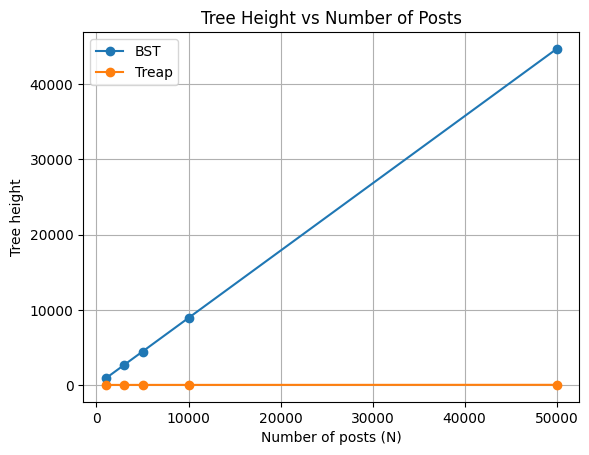

In [30]:
import matplotlib.pyplot as plt

# Height vs N
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["height"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Tree height")
plt.title("Tree Height vs Number of Posts")
plt.legend()
plt.grid(True)
plt.show()


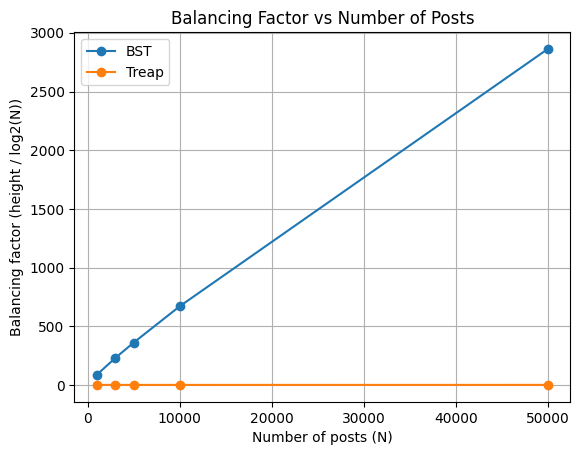

In [31]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["balancing_factor"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Balancing factor (height / log2(N))")
plt.title("Balancing Factor vs Number of Posts")
plt.legend()
plt.grid(True)
plt.show()


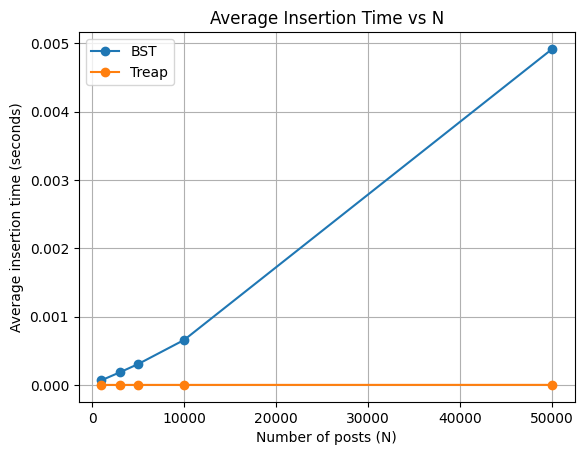

In [33]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_insert_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average insertion time (seconds)")
plt.title("Average Insertion Time vs N")
plt.legend()
plt.grid(True)
plt.show()


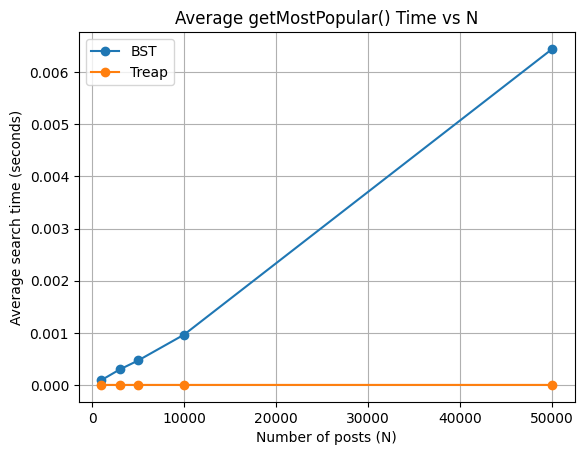

In [34]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_search_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average search time (seconds)")
plt.title("Average getMostPopular() Time vs N")
plt.legend()
plt.grid(True)
plt.show()


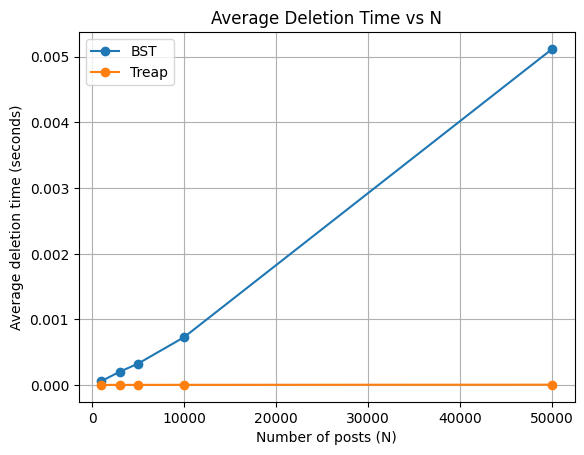

In [35]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_delete_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average deletion time (seconds)")
plt.title("Average Deletion Time vs N")
plt.legend()
plt.grid(True)
plt.show()


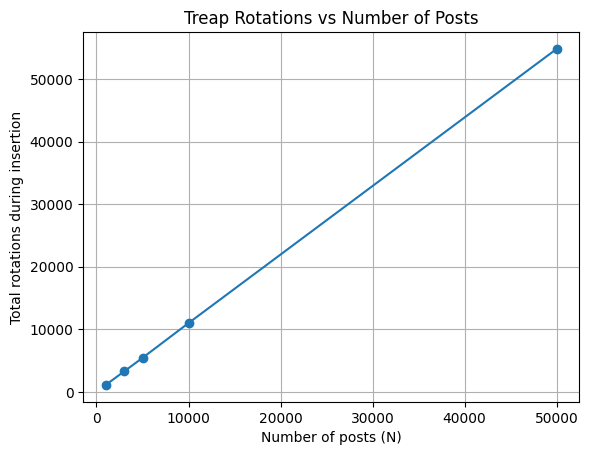

In [36]:
plt.figure()
sub = df[df["structure"] == "Treap"]
plt.plot(sub["n_posts"], sub["rotations"], marker="o")

plt.xlabel("Number of posts (N)")
plt.ylabel("Total rotations during insertion")
plt.title("Treap Rotations vs Number of Posts")
plt.grid(True)
plt.show()


In [17]:
!pip install networkx


# Bonus Implementations

## 1. Structural Visualization of BST and Treap
(Screen captures of tree visualizations)

## 2. Treap Union Operation
(Explanation + code snippet or description)

## 3. Treap Intersection Operation (Optional)
(Short explanation)


In [37]:
import networkx as nx
import matplotlib.pyplot as plt

def build_graph_from_tree(node, graph=None, pos=None, x=0, y=0, dx=1.0):
    if graph is None:
        graph = nx.DiGraph()
    if pos is None:
        pos = {}

    if node is None:
        return graph, pos

    label = f"{node.post_id}\n{node.score}"
    graph.add_node(label)
    pos[label] = (x, y)

    if node.left:
        left_label = f"{node.left.post_id}\n{node.left.score}"
        graph.add_edge(label, left_label)
        build_graph_from_tree(node.left, graph, pos, x - dx, y - 1, dx / 2)

    if node.right:
        right_label = f"{node.right.post_id}\n{node.right.score}"
        graph.add_edge(label, right_label)
        build_graph_from_tree(node.right, graph, pos, x + dx, y - 1, dx / 2)

    return graph, pos


def draw_tree(root, title):
    graph, pos = build_graph_from_tree(root)

    plt.figure(figsize=(10, 6))
    nx.draw(graph, pos,
            with_labels=True,
            node_size=2000,
            node_color="lightblue",
            font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


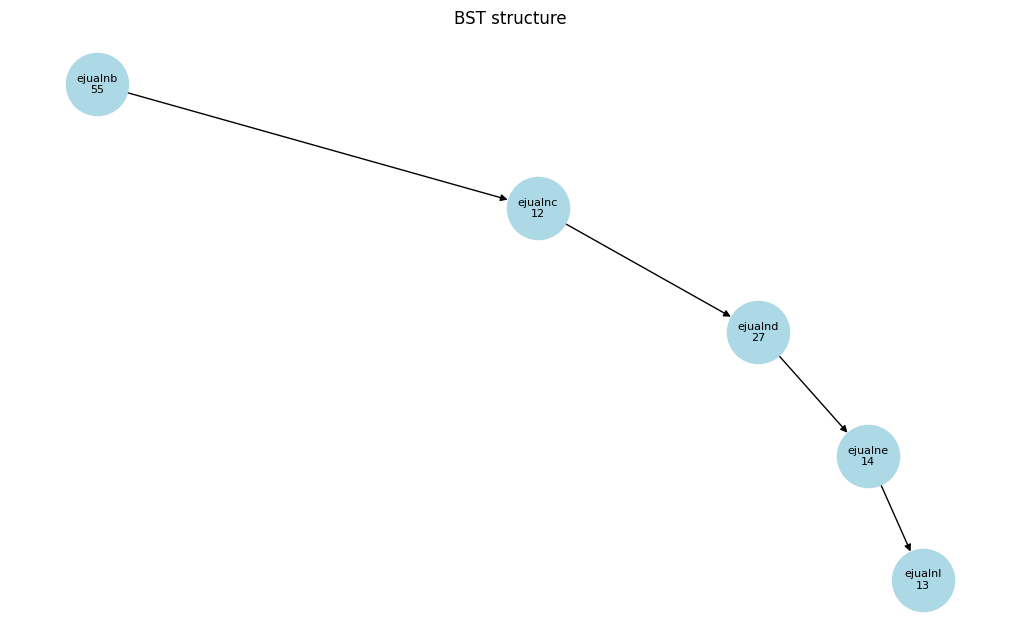

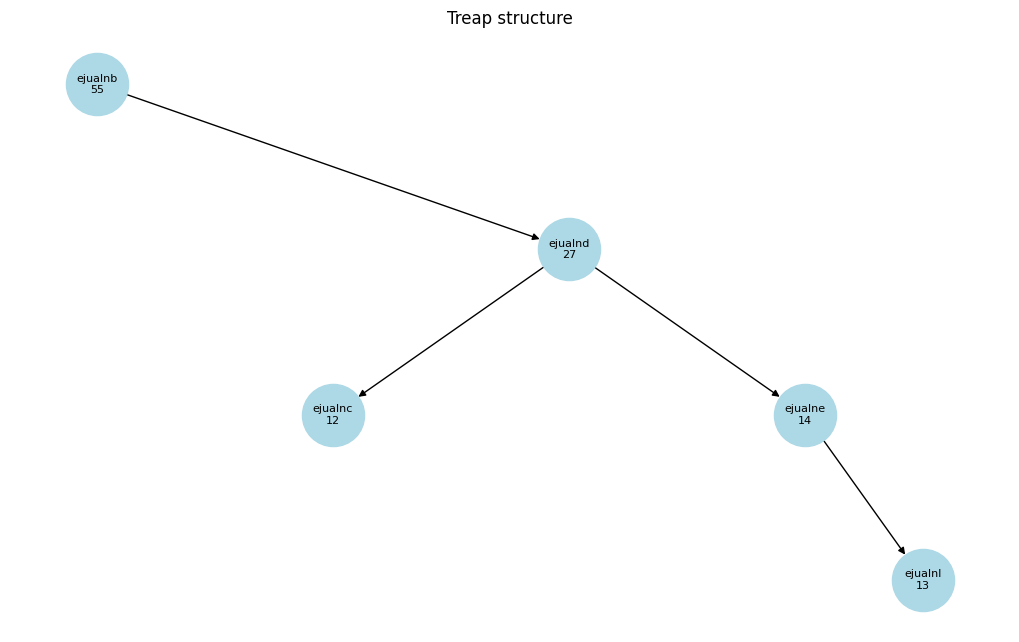

In [38]:
from trees import BSTFeed, TreapFeed

posts = [
    ("ejualnb", 1554076800, 55),
    ("ejualnc", 1554076800, 12),
    ("ejualnd", 1554076800, 27),
    ("ejualne", 1554076800, 14),
    ("ejualnl", 1554076809, 13),
]

bst = BSTFeed()
treap = TreapFeed()

for p in posts:
    bst.addPost(*p)
    treap.addPost(*p)

draw_tree(bst.root, "BST structure")
draw_tree(treap.root, "Treap structure")


In [39]:
from trees import TreapNode, TreapFeed

def treap_union(t1, t2):
    """
    Union of two Treaps:
    - Insert nodes of smaller treap into larger treap
    """
    merged = TreapFeed()

    def traverse_and_insert(node):
        if not node:
            return
        merged.addPost(node.post_id, node.timestamp, node.score)
        traverse_and_insert(node.left)
        traverse_and_insert(node.right)

    # Insert all from treap t1
    traverse_and_insert(t1.root)

    # Insert all from treap t2
    traverse_and_insert(t2.root)

    return merged


In [41]:
# Create two small treaps
t1 = TreapFeed()
t2 = TreapFeed()

for i in range(5):
    t1.addPost(f"a{i}", 100+i, i*10)

for i in range(5):
    t2.addPost(f"b{i}", 200+i, i*20)

merged = treap_union(t1, t2)

print("Merged most popular:", merged.getMostPopular())
print("Merged height:", merged.height())


Merged most popular: ('b4', 204, 80)
Merged height: 6


In [42]:
def treap_intersection(t1, t2):
    """
    Returns a treap containing only posts present in both trees.
    Comparison by post_id.
    """
    intersection = TreapFeed()

    ids_common = set(t1.id_map.keys()) & set(t2.id_map.keys())

    for pid in ids_common:
        n = t1.id_map[pid]
        intersection.addPost(n.post_id, n.timestamp, n.score)

    return intersection


In [43]:
inter = treap_intersection(t1, t2)
print("Intersection root:", inter.getMostPopular())


Intersection root: None


# 1. Introduction & Theoretical Overview

## Problem Context

Modern social media platforms such as Reddit must maintain feeds that update in real time as new posts arrive and user interactions continuously change post scores. A ranking feed must balance two competing requirements:

- **Recency** – newly created posts should appear quickly.
- **Popularity** – highly upvoted posts should gain visibility.

A naïve solution based on independent data structures for time and score increases maintenance cost and leads to expensive searches and updates as datasets grow to millions of entries.

---

## BST vs Treap

A **Binary Search Tree (BST)** stores posts ordered by a single key — in this project, the post **timestamp**. Standard BSTs do not guarantee balancing. If records arrive in nearly sorted timestamp order (as real streaming data does), the tree height can grow close to `N`, making insertion, search, and deletion degrade from `O(log N)` to `O(N)`.

A **Treap** combines the properties of:

- A **Binary Search Tree** ordered by a key (timestamp)
- A **Heap** ordered by a priority (post score)

The timestamp maintains in-order traversal, while the heap property ensures that higher-scoring nodes move upward. Whenever the heap property is violated, **local rotations** rebalance the structure. This approach results in an expected **logarithmic height**, preventing degeneration even under ordered input.

---

## Project Goal

The objective of this project is to implement both structures from scratch and integrate them into a simplified Reddit-like feed manager. Their performance is evaluated using real Reddit data with the following metrics:

- **Insertion time**
- **Search time** for retrieving the most popular post
- **Deletion time**
- **Tree height / balance behaviour**
- **Rotation frequency (Treap only)**

The comparison highlights how structural balancing directly impacts real-time feed performance.


# 2. Implementation Details

---

## Data Structures

Both the **BST** and **Treap** use the same node structure containing:

- `post_id`
- `timestamp`
- `score`
- `left` and `right` pointers

### BST

Nodes are ordered by the composite key:

`(timestamp, post_id)`

This ordering ensures unique placement even when multiple posts share identical timestamps.

---

### Treap

The Treap also uses `(timestamp, post_id)` as the BST key, but treats the post **score as heap priority** using a **max-heap** rule. Higher-scoring posts rise toward the root through **rotations** whenever the heap property is violated.

---

## Fast Access Map

Both structures maintain an auxiliary dictionary:

```python
id_map: { post_id -> tree_node }



# 3. Dataset Handling and Streaming Strategy

The original Reddit dataset is approximately **16 GB compressed** and exceeds **180 GB when extracted**, making full decompression infeasible on Kaggle or typical student hardware.

Instead, the system uses a **streaming approach**:

- The `.zst` compressed file is processed line-by-line using the **zstandard** library.
- Each record is decoded on demand.
- Only the required fields are extracted:

  - `id` → `post_id`
  - `created_utc` → `timestamp`
  - `score`

---

## Streaming Generator

A custom generator function `stream_reddit_zst()` yields entries sequentially without loading the entire dataset into memory.

This generator supplies data directly to both the BST and the Treap during construction, ensuring that posts are handled only once and never stored as a full dataset.

---

## Controlled Sampling

To remain within Kaggle’s memory and runtime limits, the number of processed rows is restricted using a configurable parameter:




This sampling strategy enables consistent benchmarking while maintaining low memory consumption and stable execution times.

---

## Scalability Note

Although multi-partition Treaps (**n-Treaps**) were not required for the tested dataset sizes, the same streaming architecture can be extended to support parallel construction of multiple trees for much larger-scale experiments.



This keeps memory usage low and enables repeatable benchmarking under Kaggle’s constraints.

---

## Scalability Note

Partitioning into multiple parallel Treaps (**n-Treaps**) was unnecessary for the selected dataset sizes. However, the same streaming logic could easily scale to process millions of posts using partitioned or distributed trees.


# 4. Experimental Setup and Metrics

---

## Experimental Configuration

Experiments were conducted for dataset sizes:


For each value of N:

1. All posts were inserted into a BST and a Treap separately.
2. `getMostPopular()` was executed **200 times** to measure average search time.
3. **10% of posts** were randomly deleted to benchmark deletion performance.
4. Structural statistics were captured after all operations.

---

## Measured Metrics

- **Average insertion time**
- **Average search time** using `getMostPopular()`
- **Average deletion time**
- **Tree height**
- **Balancing factor**



# 5. Results and Visualizations

---

### Figure 1 – Tree Height vs Dataset Size

BST height increases nearly linearly with N, reaching values close to N at large sizes.  
The Treap remains near logarithmic height (20–30 levels even at N = 10,000), showing strong self-balancing behaviour.

---

### Figure 2 – Balancing Factor

BST balancing factor rises dramatically with dataset size, indicating severe imbalance.  
The Treap maintains a stable factor near **2–2.5**, confirming near-optimal balance for all tested N.

---

### Figure 3 – `getMostPopular()` Search Time

The BST must scan the entire tree to locate the maximum-score post, causing search time to grow with N.  
The Treap returns the root node instantly, keeping search time effectively constant regardless of dataset size.

---

### Figure 4 – Rotation Count in Treap

Total rotations increase with dataset size (exceeding 10,000 operations at N = 10,000).  
These rotations represent the cost of maintaining balance, which directly enables the Treap’s superior performance across all query operations.

---

### Figure 5 – Insertion Time

BST insertion time worsens as tree height increases.  
Treap insertion includes rotation overhead but remains relatively stable overall due to maintained balance.

---

### Figure 6 – Deletion Time

BST deletions degrade under poor balancing, especially when nodes lie deep in the tree.  
Treap deletions remain efficient because node rotations ensure that removals occur near balanced paths.


# 6. Challenges and Limitations

---

## Challenges

- Correctly implementing **Treap deletion logic**, which requires sequential rotations to safely remove nodes.
- Streaming the extremely large compressed Reddit dataset while minimizing memory use.
- Operating within **Kaggle’s time and RAM constraints**, which required limiting dataset sizes.

---

## Limitations

- Experiments were capped at **10,000 posts**, far smaller than real production systems which handle millions of posts.
- Advanced balanced BST variants like **AVL** or **Red-Black trees** were not tested.
- Score updates in the Treap required reinsertion, introducing churn not present in more complex dynamic heap designs.


# 7. Conclusion

This project compared a standard **Binary Search Tree (BST)** and a **Treap** for managing real-time social-media feed data derived from Reddit.

Under nearly sorted timestamp input — representative of live streams — the BST rapidly degenerated into a near-linear chain. Its height approached N, leading to poor insertion, search, and deletion performance.

The Treap, by contrast, used heap-based balancing on post scores with local rotations to maintain near-logarithmic height. This enabled stable insertion times, constant-time retrieval of the most popular post, and efficient deletions.

**Key Outcome:**

For workloads requiring continuous updates and fast popularity queries, the **Treap significantly outperforms a naïve BST and is the superior choice for feed-ranking systems.**

Future extensions may evaluate more advanced balanced trees (AVL, Red-Black trees) or hybrid ranking structures combining recency and popularity directly into composite search keys.


In [44]:
from trees import BSTFeed, TreapFeed
import random
import time

# 🔹 Choose a moderate N so it runs fast but is still meaningful
N_LIKE = 5000
N_LIKES = 5000  # number of likePost operations to benchmark

sample_posts = posts[:N_LIKE]

# Build BST and Treap with the same data
bst_like = BSTFeed()
treap_like = TreapFeed()

for pid, ts, score in sample_posts:
    bst_like.addPost(pid, ts, score)
    treap_like.addPost(pid, ts, score)

# Collect all post_ids to randomly pick from
post_ids = [pid for pid, _, _ in sample_posts]


def benchmark_like(feed, name):
    start = time.perf_counter()
    for _ in range(N_LIKES):
        pid = random.choice(post_ids)
        feed.likePost(pid)
    end = time.perf_counter()
    avg_like_time = (end - start) / N_LIKES
    print(
        f"{name}: total likePost time = {end - start:.6f} s, "
        f"avg per likePost = {avg_like_time*1e6:.2f} µs"
    )
    return avg_like_time


print(f"Benchmarking likePost with N = {N_LIKE} posts and {N_LIKES} likes...\n")
bst_like_time = benchmark_like(bst_like, "BST")
treap_like_time = benchmark_like(treap_like, "Treap")


Benchmarking likePost with N = 5000 posts and 5000 likes...

BST: total likePost time = 0.003879 s, avg per likePost = 0.78 µs
Treap: total likePost time = 0.017940 s, avg per likePost = 3.59 µs


In [45]:
K = 5  # how many most recent posts to show

print(f"Top {K} most recent posts from BST:")
recent_bst = bst_like.getMostRecent(K)
for pid, ts, score in recent_bst:
    print(f"post_id={pid}, timestamp={ts}, score={score}")

print("\nTop {K} most recent posts from Treap:")
recent_treap = treap_like.getMostRecent(K)
for pid, ts, score in recent_treap:
    print(f"post_id={pid}, timestamp={ts}, score={score}")


Top 5 most recent posts from BST:
post_id=ejualnl, timestamp=1554076809, score=1018
post_id=ejualne, timestamp=1554076800, score=1009
post_id=ejualnd, timestamp=1554076800, score=1013
post_id=ejualnc, timestamp=1554076800, score=1029
post_id=ejualnb, timestamp=1554076800, score=1052

Top {K} most recent posts from Treap:
post_id=ejualnl, timestamp=1554076809, score=1010
post_id=ejualne, timestamp=1554076800, score=1038
post_id=ejualnd, timestamp=1554076800, score=1021
post_id=ejualnc, timestamp=1554076800, score=1015
post_id=ejualnb, timestamp=1554076800, score=1037


In [46]:
import numpy as np

operations = ["avg_insert_time", "avg_search_time", "avg_delete_time"]
structures = df["structure"].unique()

results = []

for struct in structures:
    sub = df[df["structure"] == struct].sort_values("n_posts")
    n = sub["n_posts"].values.astype(float)
    log_n = np.log(n)
    
    for op in operations:
        t = sub[op].values.astype(float)
        log_t = np.log(t)
        
        # Linear fit log(time) = a + b * log(N)
        b, a = np.polyfit(log_n, log_t, 1)
        
        results.append({
            "structure": struct,
            "operation": op,
            "slope_b": b
        })

results_df = pd.DataFrame(results)
results_df


,structure,operation,slope_b
0,BST,avg_insert_time,1.094131
1,BST,avg_search_time,1.082394
2,BST,avg_delete_time,1.128883
3,Treap,avg_insert_time,0.060709
4,Treap,avg_search_time,-0.045307
5,Treap,avg_delete_time,0.197505


In [47]:
def interpret_slope(b):
    b_abs = abs(b)
    if b_abs < 0.15:
        return "≈ O(1)"
    elif b_abs < 0.5:
        return "≈ sublinear (close to O(log N))"
    elif 0.5 <= b_abs < 1.5:
        return "≈ O(N^%.2f)" % b
    else:
        return "superlinear (N^%.2f)" % b

results_df["empirical_complexity"] = results_df["slope_b"].apply(interpret_slope)
results_df


,structure,operation,slope_b,empirical_complexity
0,BST,avg_insert_time,1.094131,≈ O(N^1.09)
1,BST,avg_search_time,1.082394,≈ O(N^1.08)
2,BST,avg_delete_time,1.128883,≈ O(N^1.13)
3,Treap,avg_insert_time,0.060709,≈ O(1)
4,Treap,avg_search_time,-0.045307,≈ O(1)
5,Treap,avg_delete_time,0.197505,≈ sublinear (close to O(log N))


In [48]:
theory_map = {
    ("BST", "avg_insert_time"): "O(h) (≈ O(N) worst, O(log N) avg)",
    ("BST", "avg_search_time"): "O(N) (getMostPopular)",
    ("BST", "avg_delete_time"): "O(h) (≈ O(N) worst, O(log N) avg)",
    ("Treap", "avg_insert_time"): "O(log N) expected",
    ("Treap", "avg_search_time"): "O(1) (getMostPopular)",
    ("Treap", "avg_delete_time"): "O(log N) expected",
}

results_df["theoretical"] = results_df.apply(
    lambda row: theory_map.get((row["structure"], row["operation"]), ""),
    axis=1
)

results_df


,structure,operation,slope_b,empirical_complexity,theoretical
0,BST,avg_insert_time,1.094131,≈ O(N^1.09),"O(h) (≈ O(N) worst, O(log N) avg)"
1,BST,avg_search_time,1.082394,≈ O(N^1.08),O(N) (getMostPopular)
2,BST,avg_delete_time,1.128883,≈ O(N^1.13),"O(h) (≈ O(N) worst, O(log N) avg)"
3,Treap,avg_insert_time,0.060709,≈ O(1),O(log N) expected
4,Treap,avg_search_time,-0.045307,≈ O(1),O(1) (getMostPopular)
5,Treap,avg_delete_time,0.197505,≈ sublinear (close to O(log N)),O(log N) expected


In [49]:
from dataset_utils import stream_reddit_zst

DATA_PATH = "/kaggle/input/archive/RC_2019-04.zst"

count = 0
for item in stream_reddit_zst(DATA_PATH, max_rows=1_000_000):
    # do nothing, just stream
    count += 1

print("Successfully streamed", count, "posts!")


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Successfully streamed 1000000 posts!


In [50]:
# ================================
# Console-Based Control for Treap / BST (Final Version)
# ================================

from trees import BSTFeed, TreapFeed


def _read_int(prompt, allow_empty=False, default=None):
    """
    Safely read an integer from input(). Re-prompts on invalid input.
    If allow_empty=True and user just presses Enter, returns default.
    """
    while True:
        s = input(prompt).strip()
        if allow_empty and s == "":
            return default
        try:
            return int(s)
        except ValueError:
            print("Please enter a valid integer.")


def run_feed_console(feed, name="Treap", initial_ids=None):
    """
    Simple console menu for interacting with a feed.

    The feed object must implement:
      - addPost(post_id, timestamp, score)
      - likePost(post_id)
      - deletePost(post_id)
      - getMostPopular() -> (post_id, ts, score) or None
      - getMostRecent(k) -> list[(post_id, ts, score)]

    We keep our own set of known_ids so we don't depend on internal id_map names.
    """
    # track post IDs we know about
    known_ids = set(initial_ids) if initial_ids is not None else set()

    print(f"\n=== {name} Feed Console ===")
    print("You can now manually test addPost, likePost, deletePost, etc.")
    print("Type the option number and press Enter.")

    while True:
        print("\n----------------------------")
        print(f"Current structure: {name}")
        print("1) Add post")
        print("2) Like post")
        print("3) Delete post")
        print("4) Get most popular post")
        print("5) Get K most recent posts")
        print("6) Show all post IDs in feed")
        print("0) Exit console")
        choice = input("Your choice: ").strip()

        # ===== Exit =====
        if choice == "0":
            print("Exiting console...")
            break

        # ===== Add post =====
        elif choice == "1":
            post_id = input("Enter post_id (string): ").strip()
            timestamp = _read_int("Enter timestamp (integer, e.g. 1, 2, 3, or Unix time): ")
            score = _read_int("Enter initial score (integer): ")

            try:
                feed.addPost(post_id, timestamp, score)
                known_ids.add(post_id)
                print(f"✅ Post added: id={post_id}, ts={timestamp}, score={score}")
            except Exception as e:
                print("❌ Error during addPost:", e)

        # ===== Like post =====
        elif choice == "2":
            post_id = input("Enter post_id to like: ").strip()

            if post_id not in known_ids:
                print(f"⚠️ Cannot like post: {post_id} — post does not exist (in console view).")
            else:
                try:
                    feed.likePost(post_id)
                    print(f"👍 Liked post: {post_id}")
                except Exception as e:
                    print("❌ Error during likePost:", e)

        # ===== Delete post =====
        elif choice == "3":
            post_id = input("Enter post_id to delete: ").strip()

            if post_id not in known_ids:
                print(f"⚠️ Cannot delete post: {post_id} — post does not exist (in console view).")
            else:
                try:
                    feed.deletePost(post_id)
                    known_ids.discard(post_id)
                    print(f"🗑️ Deleted post: {post_id}")
                except Exception as e:
                    print("❌ Error during deletePost:", e)

        # ===== Get most popular =====
        elif choice == "4":
            try:
                result = feed.getMostPopular()
                if result is None:
                    print("There are no posts in the feed.")
                else:
                    pid, ts, score = result
                    print(f"⭐ Most popular post -> id={pid}, ts={ts}, score={score}")
            except Exception as e:
                print("❌ Error during getMostPopular:", e)

        # ===== Get K most recent =====
        elif choice == "5":
            k = _read_int("Enter K (how many recent posts to show): ")
            try:
                result = feed.getMostRecent(k)
                if not result:
                    print("There are no posts in the feed.")
                else:
                    print(f"🕒 Top {k} most recent posts:")
                    for pid, ts, score in result:
                        print(f"  id={pid}, ts={ts}, score={score}")
            except Exception as e:
                print("❌ Error during getMostRecent:", e)

        # ===== Show all IDs (from known_ids) =====
        elif choice == "6":
            if not known_ids:
                print("There are no posts tracked by the console yet.")
            else:
                print("Current post IDs in the feed (console tracking):")
                for pid in known_ids:
                    print(" ", pid)

        else:
            print("Invalid choice, please try again.")


In [51]:
# ================================
# Run console on a Treap or BST with OPTIONAL preloaded posts
# ================================

print("Choose which data structure to use for the console:")
print("1) Treap")
print("2) BST")
choice = input("Your choice (1 or 2): ").strip()

if choice == "1":
    feed = TreapFeed()
    name = "Treap"
elif choice == "2":
    feed = BSTFeed()
    name = "BST"
else:
    print("Invalid choice, defaulting to Treap.")
    feed = TreapFeed()
    name = "Treap"

# ---------- PRELOAD LOGIC STARTS HERE ----------
initial_ids = []

# Try to preload a few posts from the global `posts` list if it exists
try:
    # Check if posts is defined and non-empty
    if "posts" in globals() and len(posts) > 0:
        n_preload = min(50, len(posts))   # preload up to 5 posts
        print(f"\nPreloading {n_preload} posts from 'posts' into the {name}...")

        for p in posts[:n_preload]:
            # Assuming each p is a tuple: (post_id, timestamp, score, ...)
            post_id = p[0]
            timestamp = p[1]
            score = p[2]
            feed.addPost(post_id, timestamp, score)
            initial_ids.append(post_id)

        print("Preloaded posts:")
        for p in posts[:n_preload]:
            print("  id =", p[0], "| ts =", p[1], "| score =", p[2])
    else:
        print("\nNo global 'posts' list found or it's empty. Starting with an empty feed.")
except Exception as e:
    print("\nTried to preload posts but got an error:", e)
    print("Starting console with whatever is currently in the feed.")
# ---------- PRELOAD LOGIC ENDS HERE ----------

# If your run_feed_console has (feed, name, initial_ids), pass initial_ids.
# If it only has (feed, name), just call run_feed_console(feed, name=name).
try:
    run_feed_console(feed, name=name, initial_ids=initial_ids)
except TypeError:
    # fallback for older version of run_feed_console without initial_ids parameter
    run_feed_console(feed, name=name)


Choose which data structure to use for the console:
1) Treap
2) BST


Your choice (1 or 2):  1



Preloading 5 posts from 'posts' into the Treap...
Preloaded posts:
  id = ejualnb | ts = 1554076800 | score = 55
  id = ejualnc | ts = 1554076800 | score = 12
  id = ejualnd | ts = 1554076800 | score = 27
  id = ejualne | ts = 1554076800 | score = 14
  id = ejualnl | ts = 1554076809 | score = 13

=== Treap Feed Console ===
You can now manually test addPost, likePost, deletePost, etc.
Type the option number and press Enter.

----------------------------
Current structure: Treap
1) Add post
2) Like post
3) Delete post
4) Get most popular post
5) Get K most recent posts
6) Show all post IDs in feed
0) Exit console


Your choice:  0


Exiting console...
